[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- Class Distribution ---
       Count  Percentage (%)
label                       
ham     4825       86.593683
spam     747       13.406317
--- Multinomial Naive Bayes Evaluation ---
Accuracy:  0.9812
Precision: 0.9923
Recall:    0.8658
F1-Score:  0.9247
Confusion Matrix:
 [[965   1]
 [ 20 129]] 

--- Logistic Regression Evaluation ---
Accuracy:  0.9704
Precision: 1.0000
Recall:    0.7785
F1-Score:  0.8755
Confusion Matrix:
 [[966   0]
 [ 33 116]] 



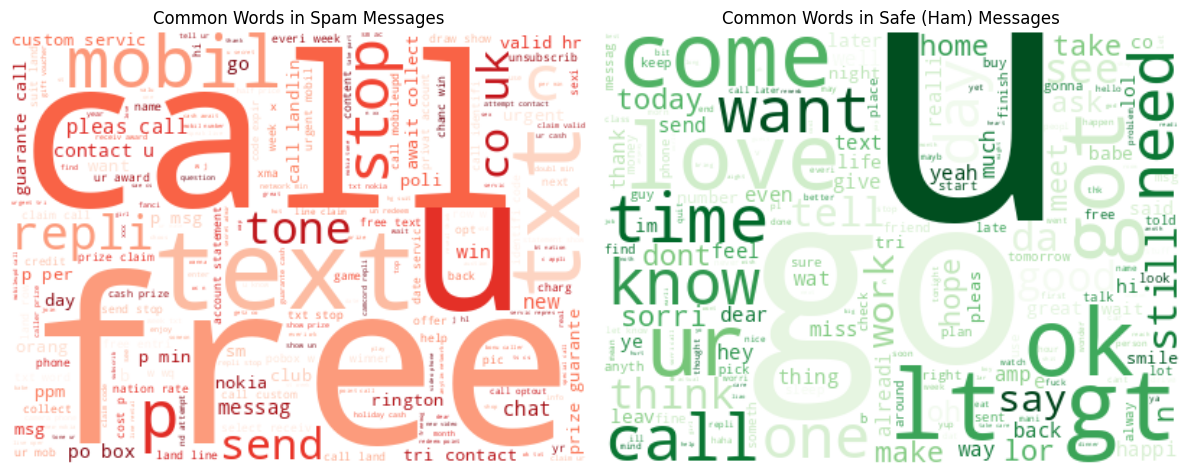

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download NLTK stopwords
nltk.download('stopwords')

# Automatically download the reliable SMS Spam Collection dataset directly via URL (No manual file upload needed!)
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv'
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

# Step 2: Class Distribution Check
print("--- Class Distribution ---")
counts = df['label'].value_counts()
percentages = df['label'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': counts, 'Percentage (%)': percentages}))

# Step 3: Text Preprocessing Pipeline
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Remove punctuation and numbers
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['cleaned_message'] = df['message'].apply(preprocess_text)

# Encode labels (ham: 0, spam: 1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Step 4: Feature Extraction using TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['cleaned_message']).toarray()
y = df['label_num']

# Step 5: Train/Test Split & Classifier Training
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Evaluation Function
def evaluate_model(y_true, y_pred, name):
    print(f"--- {name} Evaluation ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred), "\n")

evaluate_model(y_test, y_pred_nb, "Multinomial Naive Bayes")
evaluate_model(y_test, y_pred_lr, "Logistic Regression")

# Step 6: (Bonus) WordCloud Visualizations
from wordcloud import WordCloud

spam_text = " ".join(df[df['label_num'] == 1]['cleaned_message'])
ham_text = " ".join(df[df['label_num'] == 0]['cleaned_message'])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
wc_spam = WordCloud(width=400, height=300, background_color='white', colormap='Reds').generate(spam_text)
plt.imshow(wc_spam, interpolation='bilinear')
plt.title('Common Words in Spam Messages')
plt.axis('off')

plt.subplot(1, 2, 2)
wc_ham = WordCloud(width=400, height=300, background_color='white', colormap='Greens').generate(ham_text)
plt.imshow(wc_ham, interpolation='bilinear')
plt.title('Common Words in Safe (Ham) Messages')
plt.axis('off')

plt.tight_layout()
plt.show()